# Preparing the BRFSS Data

## Loading


https://www.cdc.gov/brfss/annual_data/annual_2021.html

Codebook: https://www.cdc.gov/brfss/annual_data/2021/pdf/codebook21_llcp-v2-508.pdf

In [1]:
import pandas as pd
import numpy as np

from empiricaldist import Pmf, Cdf

Read the data

In [2]:
data_file = 'LLCP2019.ASC.gz'
url = 'https://www.cdc.gov/brfss/annual_data/2019/llcp_varlayout_19_onecolumn.html'

In [3]:
tables = pd.read_html(url)
column_info = tables[0]
column_info.index = column_info['Variable Name']

In [4]:
column_info['Starting Column'] -= 1
column_info['Ending Column'] = (column_info['Starting Column'] + 
                                column_info['Field Length'])
column_info.head()

,Starting Column,Variable Name,Field Length,Ending Column
Variable Name,,,,
_STATE,0,_STATE,2,2
FMONTH,16,FMONTH,2,18
IDATE,18,IDATE,8,26
IMONTH,18,IMONTH,2,20
IDAY,20,IDAY,2,22


In [5]:
names = ['SEQNO', 'HTM4', 'WTKG3', '_SEX', '_AGEG5YR', 
         '_SMOKER3', '_VEGESU1', '_INCOMG', '_EDUCAG', '_LLCPWT']

names = ['SEQNO', 'HTM4', 'WTKG3', '_SEX', '_AGEG5YR',
         '_VEGESU1', '_INCOMG', '_LLCPWT']

In [6]:
cols = ['Starting Column', 'Ending Column']
colspecs_df = column_info.loc[names, cols]
colspecs_df

,Starting Column,Ending Column
Variable Name,,
SEQNO,35,45
HTM4,1989,1992
WTKG3,1992,1997
_SEX,1979,1980
_AGEG5YR,1980,1982
_VEGESU1,2142,2148
_INCOMG,2005,2006
_LLCPWT,1750,1760


In [7]:
colspecs = list(colspecs_df.itertuples(index=False, name=None))
colspecs

[(35, 45),
 (1989, 1992),
 (1992, 1997),
 (1979, 1980),
 (1980, 1982),
 (2142, 2148),
 (2005, 2006),
 (1750, 1760)]

In [8]:
import gzip

fp = gzip.open(data_file)

%time brfss = pd.read_fwf(fp, names=names, colspecs=colspecs)

CPU times: user 8.23 s, sys: 156 ms, total: 8.39 s
Wall time: 8.39 s


In [9]:
brfss.shape

(418268, 8)

In [10]:
brfss.head()

,SEQNO,HTM4,WTKG3,_SEX,_AGEG5YR,_VEGESU1,_INCOMG,_LLCPWT
0,2019000001,157.0,6985.0,2,13,114.0,2,135.304080
1,2019000002,163.0,4899.0,2,11,121.0,3,1454.882220
2,2019000003,165.0,8618.0,2,10,164.0,5,215.576852
3,2019000004,165.0,5534.0,2,13,NaN,4,261.282838
4,2019000005,152.0,4990.0,2,13,178.0,9,535.270103


Validate

<Axes: xlabel='HTM4'>

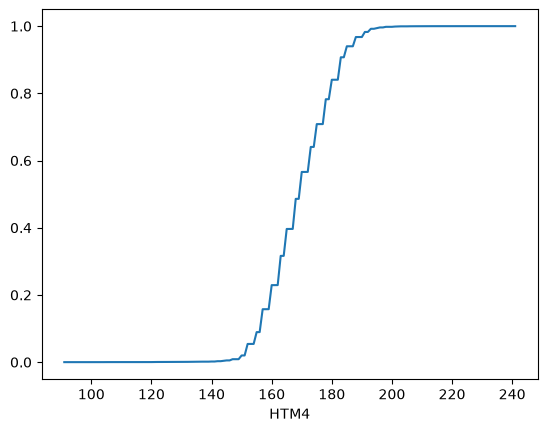

In [11]:
height = brfss['HTM4']
cdf = Cdf.from_seq(height)
cdf.plot()

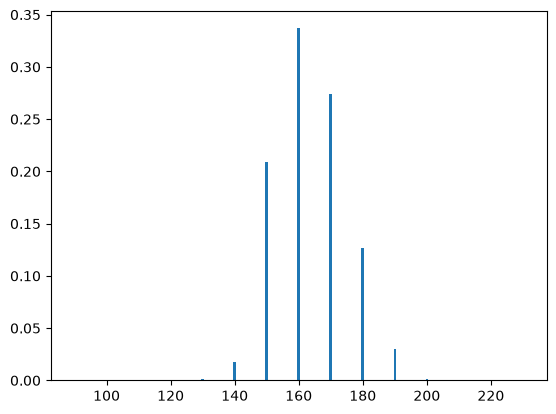

In [12]:
bins = np.arange(0, height.max(), 10)
brfss['_HTM4G10'] = pd.cut(brfss['HTM4'], bins=bins, labels=bins[:-1]).astype(float)

pmf = Pmf.from_seq(brfss['_HTM4G10'])
pmf.bar()

In [13]:
brfss['WTKG3'] /= 100
brfss['WTKG3'].describe()

count    388520.000000
mean         82.170295
std          21.025989
min          22.680000
25%          68.040000
50%          79.380000
75%          92.990000
max         281.230000
Name: WTKG3, dtype: float64

<Axes: xlabel='WTKG3'>

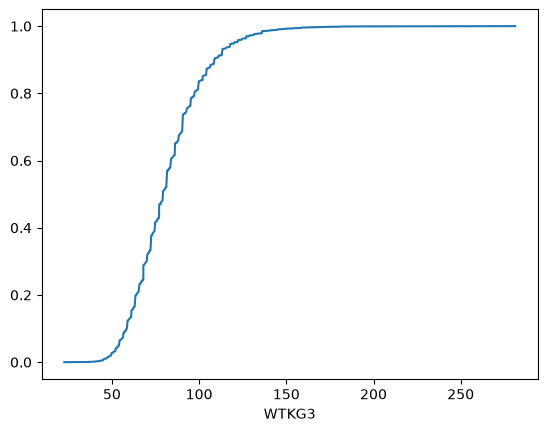

In [14]:
Cdf.from_seq(brfss['WTKG3']).plot()

To map from age groups to ages, I use the following formula, which maps each code to the approximate midpoint of its range.

In [15]:
df = pd.DataFrame(index=range(1,14))
df['AGE'] = df.index * 5 + 17
df

,AGE
1,22
2,27
3,32
4,37
5,42
6,47
7,52
8,57
9,62
10,67


In [16]:
brfss['_AGEG5YR'] = brfss['_AGEG5YR'].replace(14, np.nan)
brfss['AGE'] = brfss['_AGEG5YR'] * 5 + 17

In [17]:
brfss['AGE'].value_counts().sort_index()

AGE
22.0    25098
27.0    20817
32.0    23058
37.0    24724
42.0    24258
47.0    26075
52.0    31768
57.0    38902
62.0    44456
67.0    45206
72.0    41535
77.0    29767
82.0    35916
Name: count, dtype: int64

In [18]:
brfss['_INCOMG'] = brfss['_INCOMG'].replace(9, np.nan)
brfss['_INCOMG'].value_counts().sort_index()

_INCOMG
1.0     31982
2.0     53392
3.0     34496
4.0     46572
5.0    172045
Name: count, dtype: int64

In [19]:
brfss['_VEGESU1'] /= 100

In [20]:
bogus = (brfss['_VEGESU1'] > 10)
brfss.loc[bogus, '_VEGESU1'] = 10

<Axes: xlabel='_VEGESU1'>

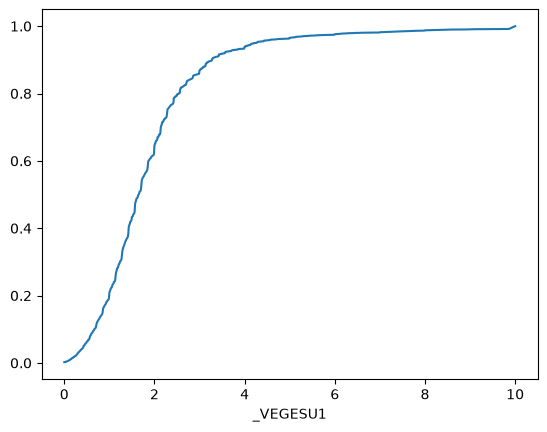

In [21]:
from empiricaldist import Cdf

cdf = Cdf.from_seq(brfss['_VEGESU1'])
cdf.plot()

Sample

In [22]:
import utils

np.random.seed(17)
sample = utils.resample_rows_weighted(brfss, '_LLCPWT')[:100000]

Write the data

In [23]:
out_file = 'brfss_2019.hdf'

In [24]:
!rm brfss_2019.hdf

rm: cannot remove 'brfss_2019.hdf': No such file or directory


In [25]:
sample.to_hdf(out_file, key='brfss', complevel=6)

In [26]:
%time brfss = pd.read_hdf(out_file, 'brfss')

CPU times: user 65.1 ms, sys: 0 ns, total: 65.1 ms
Wall time: 64.9 ms


In [27]:
!ls -lh brfss_2019.hdf

-rw-rw-r-- 1 downey downey 3.5M Sep 24 11:01 brfss_2019.hdf


In [28]:
!cp brfss_2019.hdf ../data

# add the new file to the repo from the command line

*Elements of Data Science*

Copyright 2021 [Allen B. Downey](https://allendowney.com)

License: [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/)